In [8]:
from pathlib import Path
import sys
sys.path.append(str(Path("../src").resolve()))
from constants import COLUMN_NAMES
import matplotlib.pyplot as plt
from pipeline import prepare_data

In [7]:
train_df, test_df, truth_df = prepare_data()
train_df

C:\Users\Raphael\Documents\predictive-maintenance\src\feature_engineering.py:7: FutureWarning: The provided callable <function max at 0x000001A9589EE160> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  max_cycles = train_df.groupby('id')['cycle'].transform(np.max)


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s15,s16,s17,s18,s19,s20,s21,RUL,failure_within_w1,cycle_norm
0,1,1,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662,191,0,0.000000
1,1,2,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014,190,0,0.002770
2,1,3,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375,189,0,0.005540
3,1,4,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386,188,0,0.008310
4,1,5,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502,187,0,0.011080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,0.477011,0.250000,0.0,0.0,0.686747,0.587312,0.782917,0.0,...,0.656791,0.0,0.750000,0.0,0.0,0.271318,0.109500,4,1,0.540166
20627,100,197,0.408046,0.083333,0.0,0.0,0.701807,0.729453,0.866475,0.0,...,0.727203,0.0,0.583333,0.0,0.0,0.124031,0.366197,3,1,0.542936
20628,100,198,0.522989,0.500000,0.0,0.0,0.665663,0.684979,0.775321,0.0,...,0.922278,0.0,0.833333,0.0,0.0,0.232558,0.053991,2,1,0.545706
20629,100,199,0.436782,0.750000,0.0,0.0,0.608434,0.746021,0.747468,0.0,...,0.823394,0.0,0.583333,0.0,0.0,0.116279,0.234466,1,1,0.548476


Vamos ver como os valores dos sensores variam para um ID de motor específico — digamos, ID=1.

<Axes: >

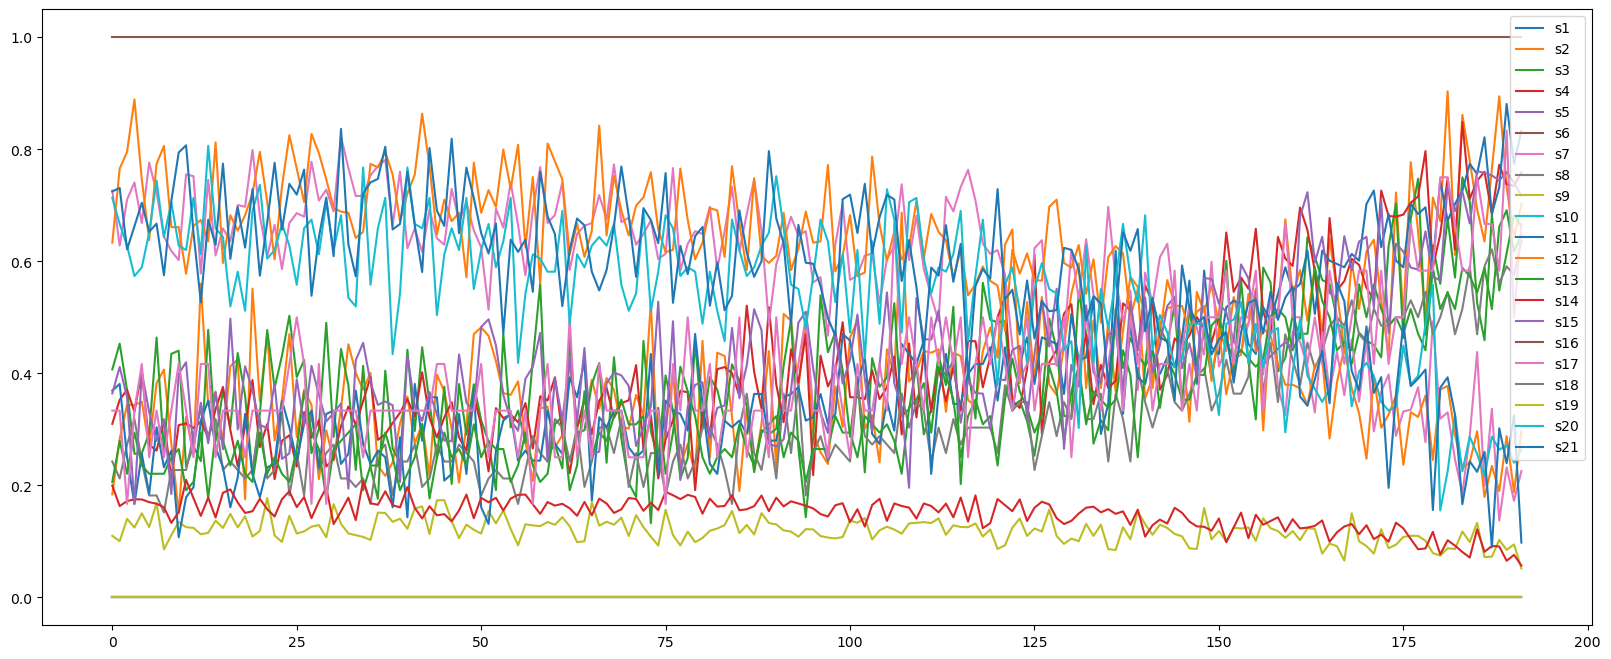

In [9]:
sensor_cols = COLUMN_NAMES[5:]
train_df[train_df.id==1][sensor_cols].plot(figsize=(20, 8))

<Axes: >

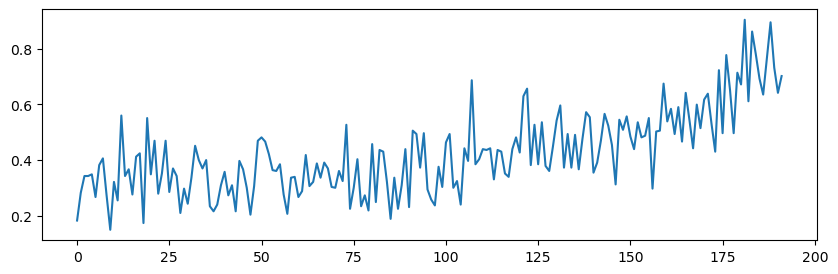

In [10]:
train_df[train_df.id==1][sensor_cols[1]].plot(figsize=(10, 3))


* Os valores do Sensor 1 aumentam à medida que o ciclo numérico aumenta.
* Os valores do Sensor 6 diminuem à medida que o ciclo numérico aumenta.
* A maioria dos outros sensores apresenta uma tendência de aumento ou de diminuição.

<Axes: >

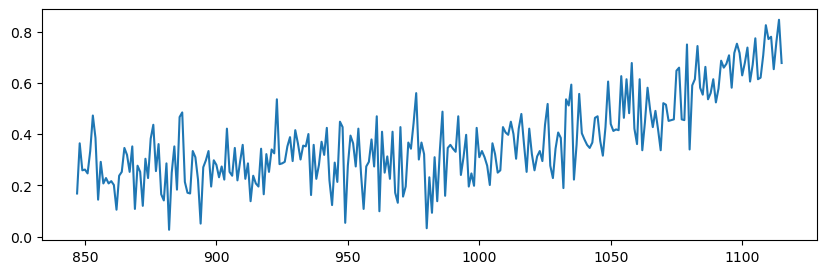

In [11]:
train_df[train_df.id==5][sensor_cols[1]].plot(figsize=(10, 3))

<Axes: >

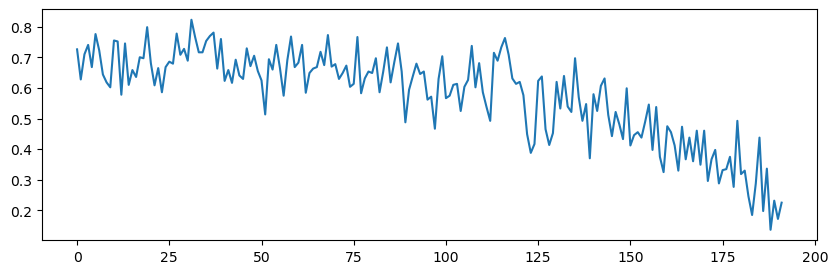

In [12]:
train_df[train_df.id==1][sensor_cols[6]].plot(figsize=(10, 3))

Traçamos as observações do sensor 1 para os IDs 1 e 5.

Ambas as observações apresentam uma tendência de alta com ciclos crescentes.

<Axes: >

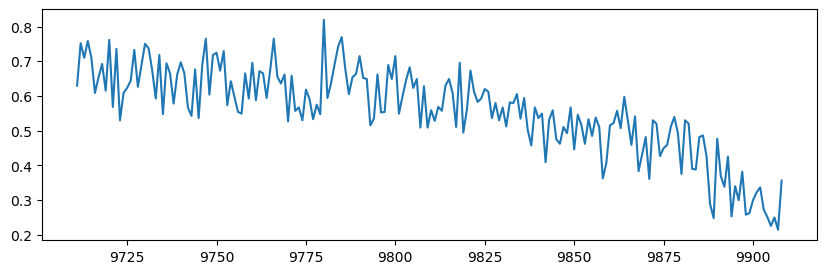

In [13]:
train_df[train_df.id==50][sensor_cols[6]].plot(figsize=(10, 3))

Plotamos as observações do sensor 6 para os IDs 1 e 50.

Ambas as observações apresentam uma tendência de queda com o aumento dos ciclos.

Podemos concluir que, quando os valores do sensor se aproximam de um determinado valor, a aeronave pode apresentar falhas em breve.